## Question 1: (Boxen Plot) Transaction Amount (log10 USD) by Device Type

1. Load credit_card_fraud_2026.csv into a pandas DataFrame.

In [50]:
import pandas as pd

df = pd.read_csv('credit_card_fraud_2026.csv')
df.head()

,transaction_id,amount_usd,merchant_category,card_type,auth_method,channel,device_type,is_foreign_transaction,hours_since_last_txn,txn_count_last_24h,...,ip_country_mismatch,billing_shipping_mismatch,cvv_retry_count,velocity_score,time_of_day_hour,day_of_week,is_ai_generated_scam_attempt,merchant_risk_score,prior_disputes,is_fraud
0,1,42.86,Restaurants,Visa,OTP,Online,Android Phone,False,13.54,2,...,False,False,0,0.1,18,3,False,42.3,0,0
1,2,4.75,Online Retail,Mastercard,3D Secure,Online,Android Phone,False,0.71,2,...,False,False,0,25.8,12,4,False,28.3,0,0
2,3,77.18,Groceries,Mastercard,3D Secure,Online,Mac,False,0.35,5,...,False,True,0,42.3,5,0,False,24.7,1,0
3,4,1.69,Streaming,Visa,No Authentication,POS,Android Phone,False,3.42,6,...,False,False,0,28.9,22,6,False,56.2,1,0
4,5,261.68,Travel,Visa,3D Secure,In-App,iPhone,False,2.43,2,...,False,False,0,3.9,2,4,False,32.7,0,0


2. Create a new column log_amount by taking the base-10 log of amount_usd (np.log10).

In [49]:
import numpy as np
df['log_amount'] = np.log10(df['amount_usd'])
df[['amount_usd', 'log_amount']].head()

,amount_usd,log_amount
0,42.86,1.632052
1,4.75,0.676694
2,77.18,1.887505
3,1.69,0.227887
4,261.68,2.417771


3. Group by device_type. There are 8 categories, so your boxen plot will have 8 boxes side by side.
4. Sort the categories from highest to lowest median log_amount before plotting (use groupby(...).median().sort_values(...) to build an order list, then pass it to the order= argument of sns.boxenplot).
5. Build the boxen plot with x='device_type', y='log_amount', a distinct color per category
(hue='device_type', palette='husl'), and clear axis titles.

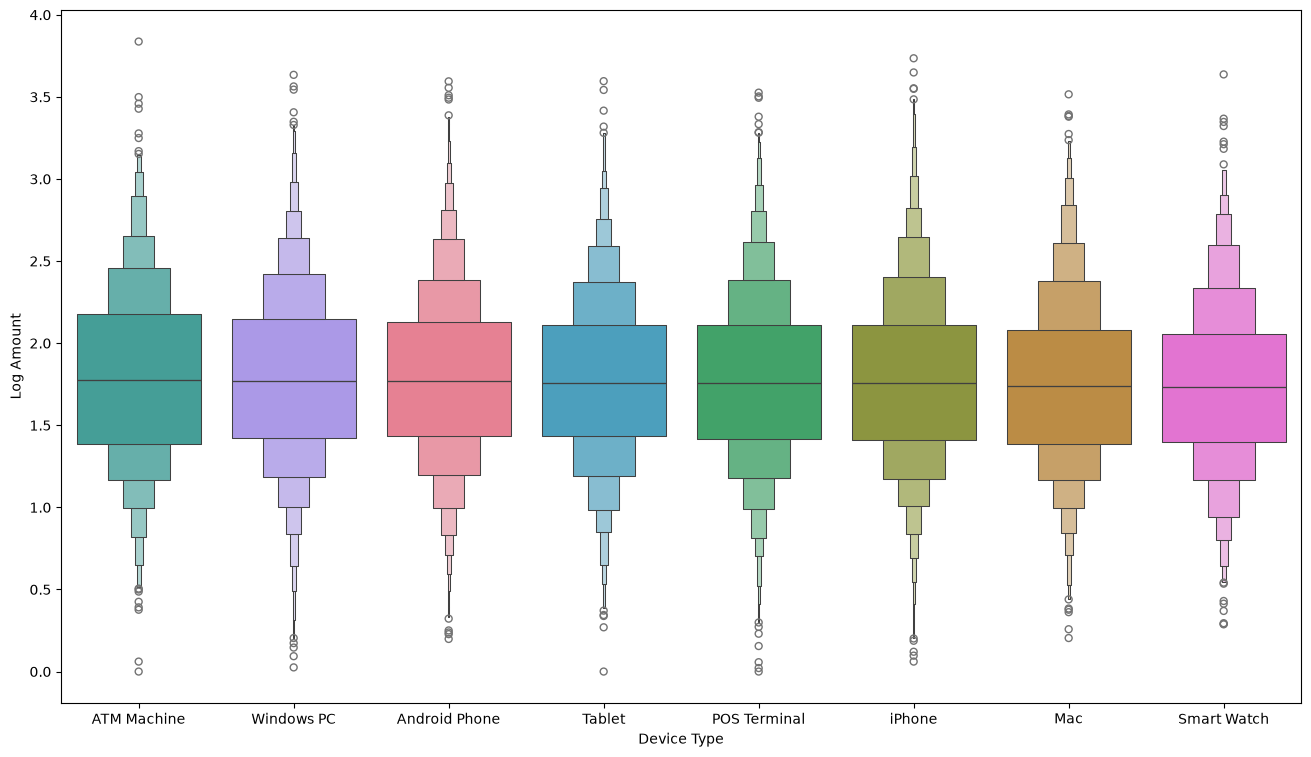

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16,9))
order = df.groupby('device_type')['log_amount'].median().sort_values(ascending=False).index
sns.boxenplot(data=df, x='device_type', y='log_amount', order=order, hue='device_type', palette='husl')
plt.xlabel('Device Type')
plt.ylabel('Log Amount')
plt.show()

i) Would you include device_type as a feature in a fraud/spending model? \
All 8 boxes look almost the same, with medians around 1.75 and similar ranges, so device type doesn't separate spending.

ii) Which device has the tightest vs. widest spread of typical transaction amounts? \
The ATM Machine is he widest, and the Smart Watch is the tightest, but the difference are small.

## Question 2: KDE Plot

A) Create a KDE plot with x='merchant_risk_score', hue='merchant_category'.

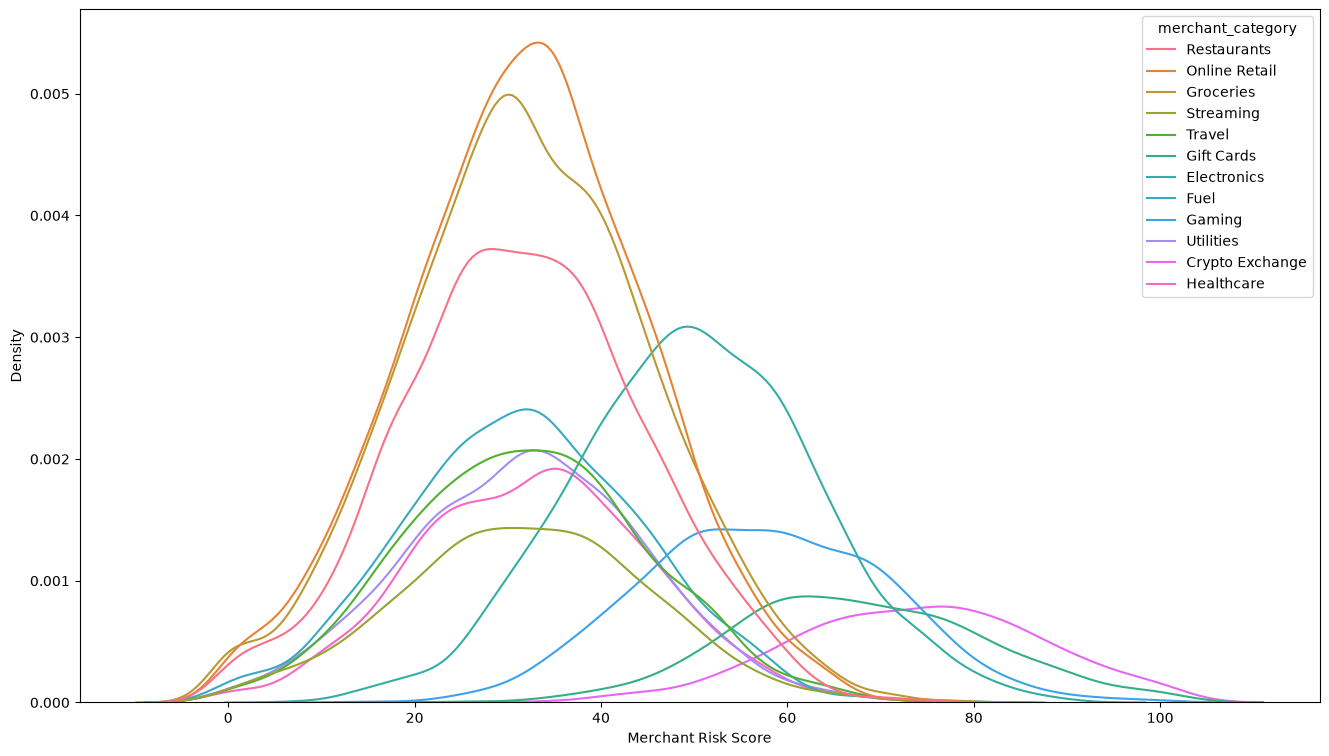

In [33]:
plt.figure(figsize=(16,9))
sns.kdeplot(data=df, x='merchant_risk_score', hue='merchant_category')
plt.xlabel('Merchant Risk Score')
plt.show()

**What do you see in the plot? Which merchant category has highest peak density in the plots and what
does that indicate?** \

Most categories are bell curve shaped and cluster around a risk score of 30. A few of them are shifted right, clustering between 50 ot 80. The merchant category wih the highest peak density is Online Retail, this indicates that most online retail merchants have a low risk score of around 30, and there are more online merchants than any other category.

**In your plot, which merchant category has the highest risks? Why is that, comment based on the
visualization.**

Crypto Exchange has the highest risk. Its curve peaks around 80 and goes out past 100, further right than anything else, indicating that it has the highest risk score.

B)
1. Create two new columns mapping the boolean flags to readable labels:
    df['foreign_status'] = df['is_foreign_transaction'].map({False: 'Domestic', True: 'Foreign'})
    df['ai_scam_status'] = df['is_ai_generated_scam_attempt'].map({False: 'Not Flagged', True: 'AI-Generated Scam'})

In [51]:
df['foreign_status'] = df['is_foreign_transaction'].map({False: 'Domestic', True: 'Foreign'})
df['ai_scam_status'] = df['is_ai_generated_scam_attempt'].map({False: 'Not Flagged', True: 'AI-Generated Scam'})
df[['foreign_status', 'is_foreign_transaction', 'ai_scam_status', 'is_ai_generated_scam_attempt']].head()

,foreign_status,is_foreign_transaction,ai_scam_status,is_ai_generated_scam_attempt
0,Domestic,False,Not Flagged,False
1,Domestic,False,Not Flagged,False
2,Domestic,False,Not Flagged,False
3,Domestic,False,Not Flagged,False
4,Domestic,False,Not Flagged,False


2. Build a figure with two side-by-side KDE plots left one showing velocity_score density by
    foreign_status, the right panel showing velocity_score density by ai_scam_status

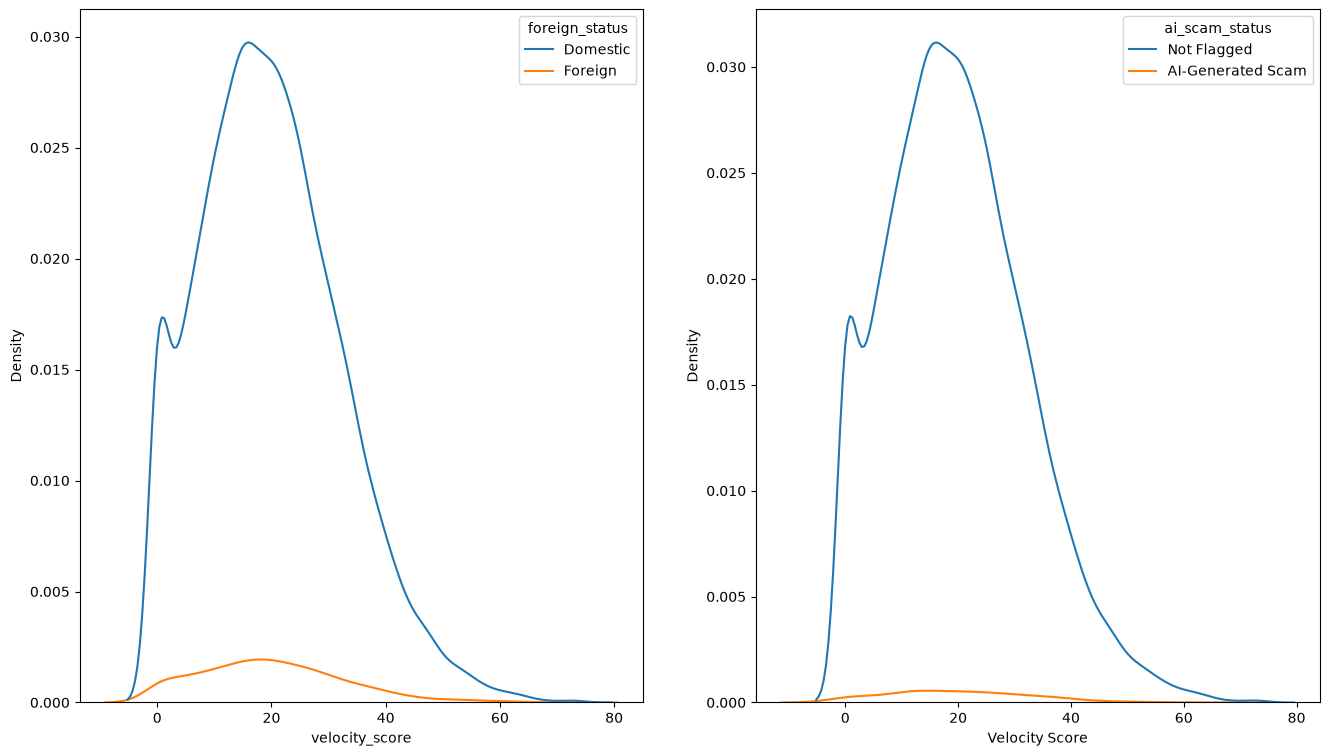

In [43]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(16,9))
sns.kdeplot(data=df, x='velocity_score', hue='foreign_status', ax=axs[0])
sns.kdeplot(data=df,  x='velocity_score', hue='ai_scam_status', ax=axs[1])
plt.xlabel('Velocity Score')
plt.show()

**What do you see in the plot: Which one: AI generated scam or Not flagged has higher density? Why?**
Not flagged has the higher density, due to how much higher the curve is.

**Which one: Foreign or Domestic why one shows higher density? Why?**
Domestic has the higher density, due to how much higher the curve is.

## Question 3: Facet Grid

Group the data by both channel and merchant_category, and compute the fraud rate (mean of is_fraud) for
each combination. Reset the index so you have a plain DataFrame with three columns: channel,
merchant_category, and is_fraud.

In [48]:
grouping = df.groupby(['channel', 'merchant_category'])['is_fraud'].mean().reset_index()
grouping.head()

,channel,merchant_category,is_fraud
0,ATM,Crypto Exchange,0.054054
1,ATM,Electronics,0.036232
2,ATM,Fuel,0.000000
3,ATM,Gaming,0.042254
4,ATM,Gift Cards,0.025000


Build the grid of panels using sns.FacetGrid() directly (not sns.catplot()): pass your grouped DataFrame,
facet by col='channel', wrap the panels with col_wrap=3, and set height=3.2, aspect=1.1.

Draw the actual bars onto that grid using g.map_dataframe(sns.barplot, ...), passing x='is_fraud',
y='merchant_category', an order= list built from df['merchant_category'].value_counts().index (so every
panel lists categories in the same order, most frequent first), and a single fixed color= so all bars match.

Finish the plot with g.set_axis_labels('Fraud Rate', ''), g.set_titles('{col_name}') so each panel shows just
its channel name, and g.fig.suptitle(...) for an overall title.

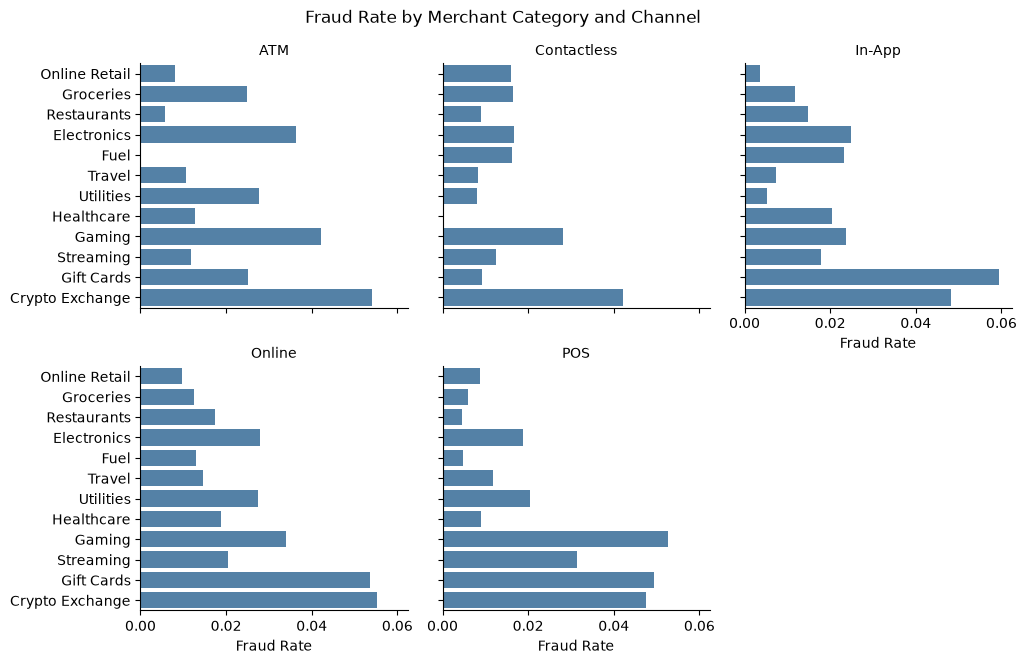

In [64]:
g = sns.FacetGrid(data=grouping, col='channel', col_wrap=3, height=3.2, aspect=1.1)
g.map_dataframe(sns.barplot, x='is_fraud', y='merchant_category', order=df['merchant_category'].value_counts().index, color='steelblue')
g.set_axis_labels('Fraud Rate', ''), g.set_titles('{col_name}')
g.figure.suptitle('Fraud Rate by Merchant Category and Channel', y=1.03)
plt.show()

**From your Facet Grid plot, which category has the highest In-App fraud rate? Which category does not
have any ATM fraud?**
Gift Cards have the highest In-App fraud rate. Fuel has no ATM fraud. Its row in the ATM panel has no bar.

See `Fashion_MNIST_Visualization_Examples.ipynb` for Question $4$, $5$ and $6$. \
See Tableau for Question $7$ and $8$. \
See `guthrie_assignment_2.html` for Question $9$ and $10$.